# Feature Engineering for Motion Phase Classification


## this notebook:
- creates time-domain features
- creates frequency-domain features
- adds a few simple engineered features
- ranks features for model use
- checks correlation among the top features
- saves clean outputs for the us

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.preprocessing import LabelEncoder

In [2]:
DATA_PATH = "biosensor_dataset_with_target.csv"
OUT_DIR = "out/feature_engineering"
PLOT_DIR = os.path.join(OUT_DIR, "plots")

WINDOW_SECONDS = 1.0
STEP_RATIO = 0.5
TOP_K = 15

RAW_SENSOR_COLS = [
    "Heart_Rate", "Acc_X", "Acc_Y", "Acc_Z",
    "Gyro_X", "Gyro_Y", "Gyro_Z"
]

os.makedirs(PLOT_DIR, exist_ok=True)

## Load and clean the raw dataset

Used the raw timestamped sensor data so we can compute both time-domain and frequency-domain features.


In [3]:
df = pd.read_csv(DATA_PATH)

df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.dropna(subset=["Timestamp"]).sort_values(["Athlete_ID", "Timestamp"]).copy()
df["Event_Label"] = df["Event_Label"].astype(str).str.strip()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if df[numeric_cols].isna().sum().sum() > 0:
    df[numeric_cols] = (
        df.groupby("Athlete_ID")[numeric_cols]
        .transform(lambda group: group.interpolate(method="linear", limit_direction="both"))
    )

df["Acc_Mag"] = np.sqrt(df["Acc_X"]**2 + df["Acc_Y"]**2 + df["Acc_Z"]**2)
df["Gyro_Mag"] = np.sqrt(df["Gyro_X"]**2 + df["Gyro_Y"]**2 + df["Gyro_Z"]**2)

df.head()

,Heart_Rate,Acc_X,Acc_Y,Acc_Z,Gyro_X,Gyro_Y,Gyro_Z,Event_Label,Timestamp,Athlete_ID,Acc_Mag,Gyro_Mag
0,166,-2.598157,2.205079,-0.649084,-48.457966,15.407057,164.550534,Accel,2025-05-11 12:14:53.417747,A001,3.469021,172.227844
1,159,-2.862471,2.173831,-2.054184,5.137738,34.974254,-15.283653,Jump_Takeoff,2025-05-11 12:14:53.517747,A001,4.139922,38.512139
2,120,-1.045441,2.755975,2.696018,-175.960480,-107.481553,177.757215,Stop,2025-05-11 12:14:53.617747,A001,3.994603,272.235197
3,119,2.931939,0.005220,-1.835028,-8.255970,131.909447,-172.149554,Sprint_Mid,2025-05-11 12:14:53.717747,A001,3.458847,217.033943
4,121,2.517730,1.217080,1.611578,-44.266911,147.303725,104.186863,Start_Run,2025-05-11 12:14:53.817747,A001,3.227605,185.776342


## Estimate sampling rate

The frequency features need a sampling rate, so we estimate it from the timestamp spacing.


In [4]:
dt = df.groupby("Athlete_ID")["Timestamp"].diff().dt.total_seconds().dropna()
dt = dt[dt > 0]

sampling_rate_hz = 1.0 / dt.median()
sampling_rate_hz

np.float64(10.0)

## Helper functions

These functions compute:
- zero-crossing rate
- frequency-based features
- safe correlations between axes


In [5]:
def zero_crossing_rate(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return 0.0

    
    centered = x - np.mean(x)
    signs = np.sign(centered)

    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]

    
    if signs[0] == 0:
        signs[0] = 1

    crossings = np.sum(signs[:-1] * signs[1:] < 0)
    return float(crossings / (len(x) - 1))


In [6]:
def spectral_features(x, sampling_rate_hz):
    x = np.asarray(x, dtype=float)
    n = len(x)

    if n < 2:
        return 0.0, 0.0, 0.0

    
    centered = x - np.mean(x)
    power = np.abs(rfft(centered)) ** 2
    freqs = rfftfreq(n, d=1.0 / sampling_rate_hz)

    if len(power) <= 1:
        dominant_freq = 0.0
    else:
        dominant_index = int(np.argmax(power[1:])) + 1
        dominant_freq = float(freqs[dominant_index])

    spectral_energy = float(np.sum(power) / n)

    
    power_sum = np.sum(power)
    if power_sum <= 0 or len(power) <= 1:
        spectral_entropy = 0.0
    else:
        prob = power / power_sum
        spectral_entropy = float(-np.sum(prob * np.log2(prob + 1e-12)) / np.log2(len(prob)))

    return dominant_freq, spectral_energy, spectral_entropy



In [7]:
def safe_corr(a, b):
    
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    
    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return 0.0

    return float(np.corrcoef(a, b)[0, 1])

## Extract window-level features

For each window,computee:
- time-domain: mean, standard deviation, RMS, zero-crossing rate
- frequency-domain: dominant frequency, spectral energy, spectral entropy
- engineered features: acceleration magnitude, gyroscope magnitude, and axis-pair correlations


In [8]:
def extract_window_features(df, sampling_rate_hz, window_seconds=1.0, step_ratio=0.5):
    signal_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]

    window_delta = pd.to_timedelta(window_seconds, unit="s")
    step_seconds = max(window_seconds * step_ratio, 0.1)
    step_delta = pd.to_timedelta(step_seconds, unit="s")

    
    rows = []

    for athlete_id, athlete_df in df.groupby("Athlete_ID", sort=False):
        athlete_df = athlete_df.sort_values("Timestamp")

        start_time = athlete_df["Timestamp"].min()
        end_time = athlete_df["Timestamp"].max()
        current_time = start_time

        while current_time + window_delta <= end_time:
            window_end = current_time + window_delta

            win_df = athlete_df[
                (athlete_df["Timestamp"] >= current_time) &
                (athlete_df["Timestamp"] < window_end)
            ]

            
            if not win_df.empty:
                label_counts = win_df["Event_Label"].value_counts()

                row = {
                    "Athlete_ID": athlete_id,
                    "window_start": current_time,
                    "window_end": window_end,
                    "window_seconds": window_seconds,
                    "step_seconds": step_seconds,
                    "n_samples": int(len(win_df)),
                    "Event_Label": label_counts.index[0],
                    "label_purity": float(label_counts.iloc[0] / len(win_df))
                }

                
                for col in signal_cols:
                    x = win_df[col].to_numpy(dtype=float)

                    row[f"{col}_mean"] = float(np.mean(x))
                    row[f"{col}_std"] = float(np.std(x, ddof=0))
                    row[f"{col}_rms"] = float(np.sqrt(np.mean(np.square(x))))
                    row[f"{col}_zcr"] = zero_crossing_rate(x)

                    dom_freq, spec_energy, spec_entropy = spectral_features(x, sampling_rate_hz)
                    row[f"{col}_dom_freq"] = dom_freq
                    row[f"{col}_spec_energy"] = spec_energy
                    row[f"{col}_spec_entropy"] = spec_entropy

                row["Acc_XY_corr"] = safe_corr(win_df["Acc_X"], win_df["Acc_Y"])
                row["Acc_XZ_corr"] = safe_corr(win_df["Acc_X"], win_df["Acc_Z"])
                row["Acc_YZ_corr"] = safe_corr(win_df["Acc_Y"], win_df["Acc_Z"])
                row["Gyro_XY_corr"] = safe_corr(win_df["Gyro_X"], win_df["Gyro_Y"])
                row["Gyro_XZ_corr"] = safe_corr(win_df["Gyro_X"], win_df["Gyro_Z"])
                row["Gyro_YZ_corr"] = safe_corr(win_df["Gyro_Y"], win_df["Gyro_Z"])

                rows.append(row)

            current_time += step_delta

    return pd.DataFrame(rows)



feature_df = extract_window_features(
    df=df,
    sampling_rate_hz=sampling_rate_hz,
    window_seconds=WINDOW_SECONDS,
    step_ratio=STEP_RATIO
)


feature_df.to_csv(f"{OUT_DIR}/engineered_features_w1p0s.csv", index=False)

print(feature_df.shape)
feature_df.head()

(290, 77)


,Athlete_ID,window_start,window_end,window_seconds,step_seconds,n_samples,Event_Label,label_purity,Heart_Rate_mean,Heart_Rate_std,...,Gyro_Mag_zcr,Gyro_Mag_dom_freq,Gyro_Mag_spec_energy,Gyro_Mag_spec_entropy,Acc_XY_corr,Acc_XZ_corr,Acc_YZ_corr,Gyro_XY_corr,Gyro_XZ_corr,Gyro_YZ_corr
0,A001,2025-05-11 12:14:53.417747,2025-05-11 12:14:54.417747,1.0,0.5,10,Sprint_Mid,0.3,127.4,29.742898,...,0.333333,1.0,20998.721475,0.832340,-0.217428,0.278569,0.272394,0.589824,-0.637565,-0.638864
1,A001,2025-05-11 12:14:53.917747,2025-05-11 12:14:54.917747,1.0,0.5,10,Landing,0.4,131.5,36.450652,...,0.222222,1.0,6828.770710,0.408626,-0.217097,0.251166,0.262237,-0.186111,-0.301849,0.162683
2,A001,2025-05-11 12:14:54.417747,2025-05-11 12:14:55.417747,1.0,0.5,10,Accel,0.4,143.0,29.199315,...,0.555556,4.0,12757.447849,0.776220,-0.105243,-0.174815,-0.092470,-0.031770,-0.194218,-0.043209
3,A001,2025-05-11 12:14:54.917747,2025-05-11 12:14:55.917747,1.0,0.5,10,Accel,0.3,132.4,26.192365,...,0.777778,5.0,13602.651832,0.771407,0.448190,-0.241209,-0.077704,-0.294522,-0.273253,-0.002142
4,A001,2025-05-11 12:14:55.417747,2025-05-11 12:14:56.417747,1.0,0.5,10,Start_Run,0.3,132.8,33.391017,...,0.666667,5.0,8202.929713,0.779429,0.451788,-0.399431,-0.196002,0.115624,-0.380576,0.469158


## Rank and select features

remove identifier columns and rank the sensor features using:
- mutual information
- ANOVA F-score
- Random Forest importance

Then keep the top features for correlation checking and later modeling.


In [9]:
drop_cols = [
    "Athlete_ID", "window_start", "window_end", "window_seconds",
    "step_seconds", "Event_Label", "n_samples", "label_purity"
]

X = feature_df.drop(columns=drop_cols, errors="ignore").copy()
y = feature_df["Event_Label"].copy()

constant_features = X.columns[X.nunique(dropna=False) <= 1].tolist()
if constant_features:
    X = X.drop(columns=constant_features)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

mi = mutual_info_classif(X, y_encoded, random_state=42)
f_scores, p_values = f_classif(X, y_encoded)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X, y)

ranking_df = pd.DataFrame({
    "feature": X.columns,
    "mutual_info": mi,
    "anova_f": f_scores,
    "p_value": p_values,
    "rf_importance": rf.feature_importances_
})

ranking_df["mi_rank"] = ranking_df["mutual_info"].rank(ascending=False, method="average")
ranking_df["anova_rank"] = ranking_df["anova_f"].rank(ascending=False, method="average")
ranking_df["rf_rank"] = ranking_df["rf_importance"].rank(ascending=False, method="average")
ranking_df["avg_rank"] = ranking_df[["mi_rank", "anova_rank", "rf_rank"]].mean(axis=1)

ranking_df = ranking_df.sort_values(
    ["avg_rank", "rf_importance", "mutual_info"],
    ascending=[True, False, False]
).reset_index(drop=True)

top_features = ranking_df.head(TOP_K)["feature"].tolist()

selected_df = feature_df[top_features + ["Event_Label"]].copy()

ranking_df.to_csv(f"{OUT_DIR}/feature_ranking_w1p0s.csv", index=False)
selected_df.to_csv(f"{OUT_DIR}/selected_top15_features_w1p0s.csv", index=False)

ranking_df.head(TOP_K)

,feature,mutual_info,anova_f,p_value,rf_importance,mi_rank,anova_rank,rf_rank,avg_rank
0,Acc_Mag_std,0.057532,2.357470,0.040541,0.018707,6.0,8.0,11.0,8.333333
1,Heart_Rate_mean,0.021833,2.367466,0.039784,0.020736,16.0,7.0,5.0,9.333333
2,Heart_Rate_rms,0.039896,2.240349,0.050511,0.020700,11.0,11.0,6.0,9.333333
3,Gyro_X_spec_entropy,0.005150,4.029542,0.001506,0.024624,31.0,1.0,1.0,11.000000
4,Gyro_YZ_corr,0.025538,2.608825,0.025121,0.017978,14.0,4.0,16.0,11.333333
5,Gyro_Y_mean,0.002855,2.790907,0.017674,0.021924,33.0,3.0,3.0,13.000000
6,Gyro_Y_rms,0.019932,1.675271,0.140528,0.018814,17.0,13.0,10.0,13.333333
7,Acc_YZ_corr,0.061697,0.981532,0.429283,0.021035,5.0,34.0,4.0,14.333333
8,Acc_XZ_corr,0.016299,1.902542,0.093924,0.018154,20.0,12.0,15.0,15.666667
9,Gyro_Z_spec_energy,0.043644,1.481563,0.195796,0.016608,9.0,17.0,22.0,16.000000


## Correlation analysis and simple plots

plots below are saved to the output folder.


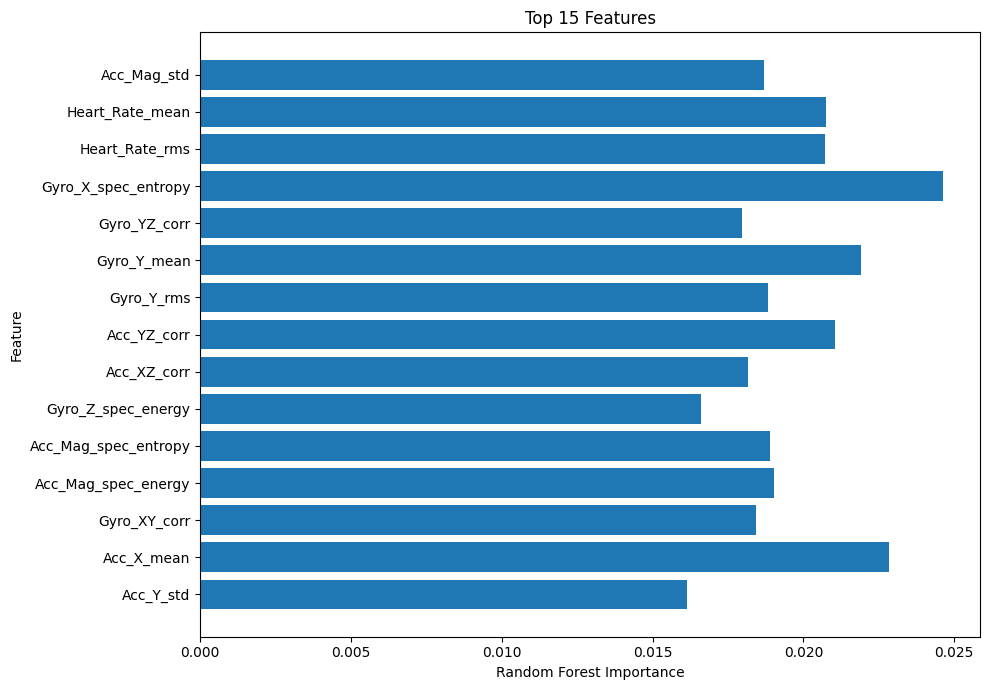

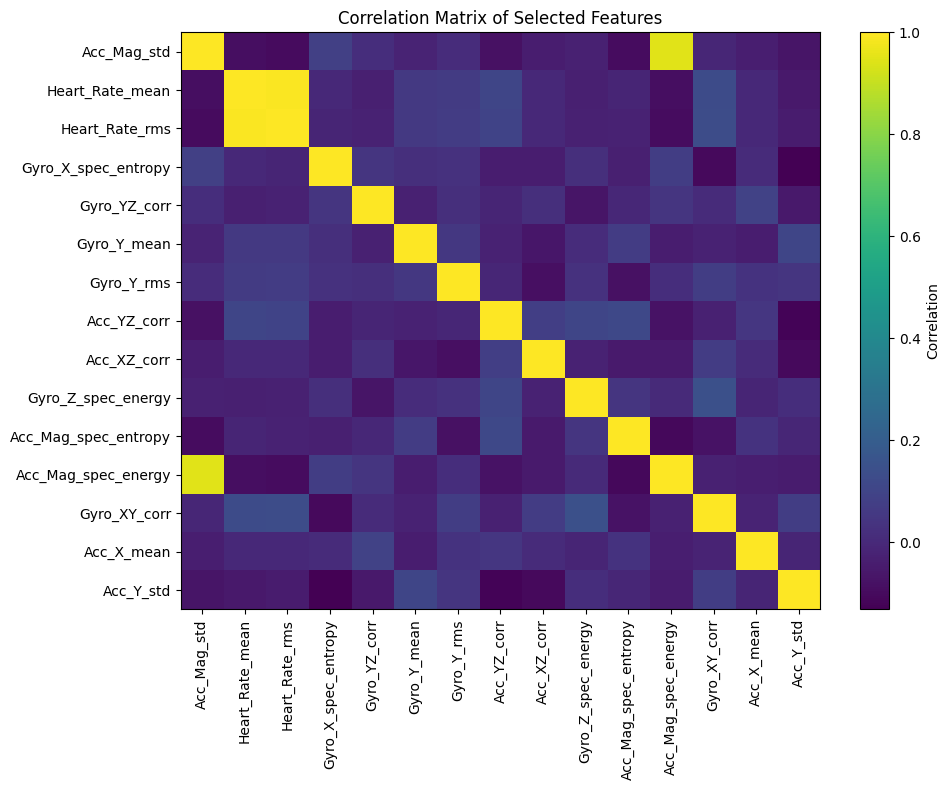

In [10]:
corr_df = feature_df[top_features].corr()
corr_df.to_csv(f"{OUT_DIR}/feature_correlation_w1p0s.csv")

top = ranking_df.head(TOP_K).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["rf_importance"])
plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.title(f"Top {TOP_K} Features")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/feature_importance_bar_w1p0s.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(corr_df.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/feature_correlation_heatmap_w1p0s.png", dpi=300, bbox_inches="tight")
plt.show()

## notes

- Time-domain features used: mean, standard deviation, RMS, and zero-crossing rate.
- Frequency-domain features used: dominant frequency, spectral energy, and spectral entropy.
- Engineered features added: acceleration magnitude, gyroscope magnitude, and axis-pair correlations.
- Features were ranked using mutual information, ANOVA F-score, and Random Forest importance.
- label_purity, timestamps, and Athlete_ID should **not** be used as model inputs because they are identifiers or may leak structure instead of true sensor behavior.
